## Are the enriched GO terms driven by the GC bias, or orthogonal to it?

`goseq` (Young et al. 2010) corrects GO enrichment for a covariate bias. We use **GC content**
as the bias: it fits a probability weighting function `P(gene is DE | GC)`, then tests each term
with a **Wallenius non-central hypergeometric** test whose odds come from the PWF, inflating the
null for terms full of GC-extreme genes.

For each side we compute both the **naive** (`method="Hypergeometric"`) and the **GC-corrected**
(`method="Wallenius"`, default) enrichment, then classify every term:
- **GC-robust** — significant under both → enrichment is *orthogonal* to the GC bias.
- **GC-driven** — significant naively but not after correction → a GC artifact.

Gene→category membership is rebuilt from the **same Enrichr libraries** the original enrichment
used, so the verdict maps onto the exact terms that popped out. DE status + GC are read from the
existing pipeline outputs (`results.csv` + cached `gene_metrics`).

> Prereq: `results.csv` in this folder must be the current PolyTvRandO run (re-run
> `human_edgepy.ipynb` if unsure). Fetching the Enrichr GMTs needs network.

In [1]:
library(goseq)

# --- Rebuild the GO gene sets used for the enrichment as a gene->category map ---
LIBRARIES <- c("GO_Biological_Process_2026", "GO_Molecular_Function_2026",
               "GO_Cellular_Component_2026")

fetch_enrichr_gmt <- function(lib) {
  u <- paste0("https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=", lib)
  con <- url(u); on.exit(close(con))
  parts <- strsplit(readLines(con, warn = FALSE), "\t")
  do.call(rbind, lapply(parts, function(p) {
    genes <- p[-(1:2)]                          # cols 1-2 are the term name + description
    genes <- toupper(sub(",.*$", "", genes[genes != ""]))   # drop any ",weight" suffix
    if (length(genes) == 0) return(NULL)
    data.frame(gene = genes, category = paste0(lib, "::", p[1]), stringsAsFactors = FALSE)
  }))
}

gene2cat <- unique(do.call(rbind, lapply(LIBRARIES, fetch_enrichr_gmt)))
cat(sprintf("gene2cat: %d categories, %d genes, %d edges\n",
            length(unique(gene2cat$category)), length(unique(gene2cat$gene)), nrow(gene2cat)))

Loading required package: BiasedUrn

Loading required package: geneLenDataBase





gene2cat: 7858 categories, 17097 genes, 279862 edges


In [2]:
# --- Per-gene DE status + GC bias, from existing pipeline outputs ---
res <- read.csv("results.csv", stringsAsFactors = FALSE)   # gene_name, logFC, FDR, ...
gm  <- read.csv("/home/mcaskey/10XvParse/Notebooks/gene_info/human/gene_metrics_detailed.csv",
                stringsAsFactors = FALSE)                    # gene_name, gc_median_tx, ...

res$gene <- toupper(res$gene_name)
gm$gene  <- toupper(gm$gene_name)
res <- merge(res, gm[, c("gene", "gc_median_tx")], by = "gene", all.x = TRUE)
res <- res[!duplicated(res$gene) & !is.na(res$gc_median_tx), ]

gene2cat <- gene2cat[gene2cat$gene %in% res$gene, ]          # restrict categories to the universe

FDR <- 0.01
cat(sprintf("universe = %d genes with GC; %d significant at FDR < %g\n",
            nrow(res), sum(res$FDR < FDR), FDR))

universe = 25722 genes with GC; 10773 significant at FDR < 0.01


Using manually entered categories.

For 12673 genes, we could not find any categories. These genes will be excluded.

To force their use, please run with use_genes_without_cat=TRUE (see documentation).

This was the default behavior for version 1.15.1 and earlier.

Calculating the p-values...

Using manually entered categories.

For 12673 genes, we could not find any categories. These genes will be excluded.

To force their use, please run with use_genes_without_cat=TRUE (see documentation).

This was the default behavior for version 1.15.1 and earlier.

Calculating the p-values...

Warning message in pcls(G):
“initial point very close to some inequality constraints”


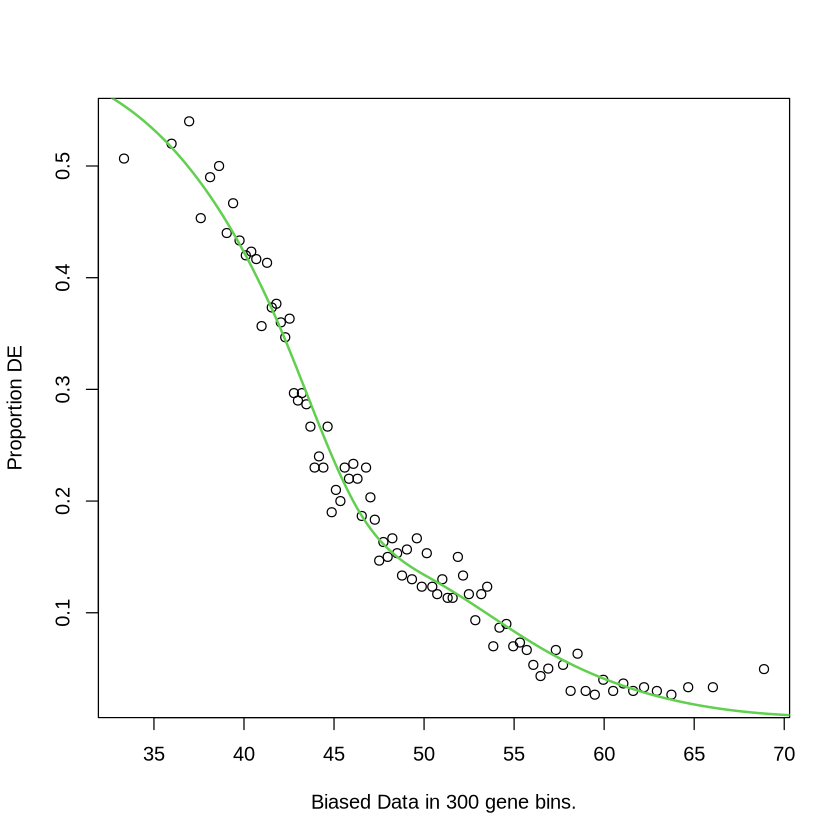

Using manually entered categories.

For 12673 genes, we could not find any categories. These genes will be excluded.

To force their use, please run with use_genes_without_cat=TRUE (see documentation).

This was the default behavior for version 1.15.1 and earlier.

Calculating the p-values...

Using manually entered categories.

For 12673 genes, we could not find any categories. These genes will be excluded.

To force their use, please run with use_genes_without_cat=TRUE (see documentation).

This was the default behavior for version 1.15.1 and earlier.

Calculating the p-values...



polyT: 34 GC-robust, 14 GC-driven (of 48 naively significant)
randO: 2 GC-robust, 37 GC-driven (of 39 naively significant)


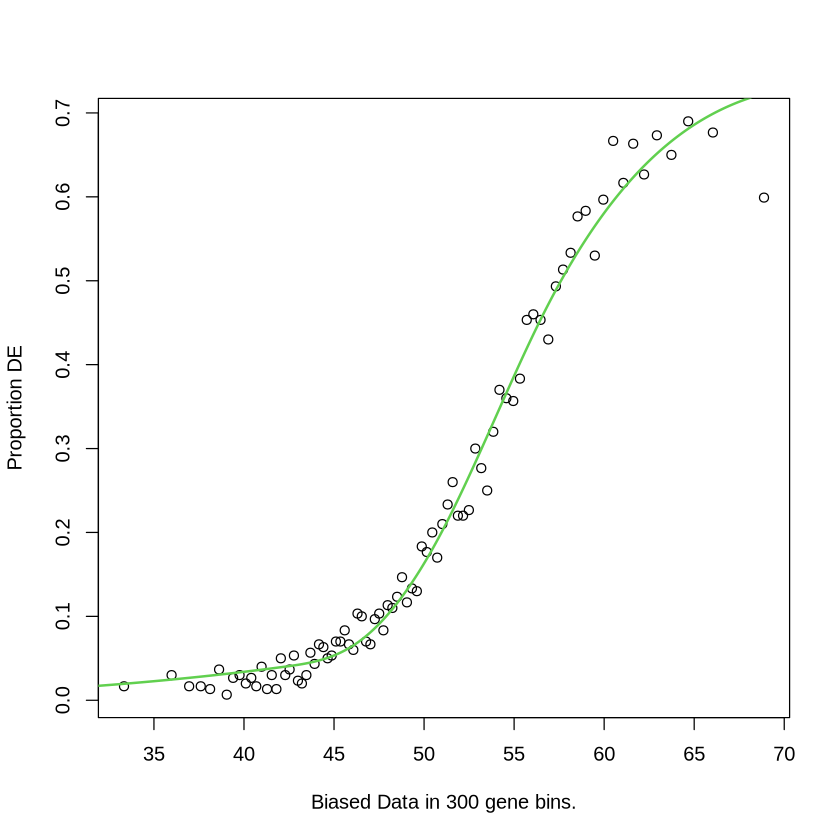

In [3]:
# --- Run goseq per side: Wallenius = GC-corrected, Hypergeometric = naive ---
run_goseq_side <- function(res, gene2cat, de_mask, bias_col = "gc_median_tx") {
  de <- as.integer(de_mask); names(de) <- res$gene
  pwf <- nullp(de, bias.data = res[[bias_col]], plot.fit = TRUE)   # PWF: P(DE | GC)

  wal <- goseq(pwf, gene2cat = gene2cat)                              # GC-corrected (Wallenius)
  hyp <- goseq(pwf, gene2cat = gene2cat, method = "Hypergeometric")  # naive

  m <- merge(wal[, c("category", "over_represented_pvalue", "numDEInCat", "numInCat")],
             hyp[, c("category", "over_represented_pvalue")],
             by = "category", suffixes = c("_wal", "_naive"))
  # BH-correct WITHIN each ontology (the "db::" prefix), not pooled across databases
  m$db <- sub("::.*", "", m$category)
  m$padj_wal   <- ave(m$over_represented_pvalue_wal,   m$db, FUN = function(p) p.adjust(p, "BH"))
  m$padj_naive <- ave(m$over_represented_pvalue_naive, m$db, FUN = function(p) p.adjust(p, "BH"))
  m$classification <- ifelse(m$padj_naive < 0.05 & m$padj_wal <  0.05, "GC-robust",
                      ifelse(m$padj_naive < 0.05 & m$padj_wal >= 0.05, "GC-driven", "n.s."))
  m[order(m$over_represented_pvalue_wal), ]
}

# COMPARING = polyT (side1) vs randO (side2); logFC = randO / polyT  -> flip signs if yours differs
polyT_res <- run_goseq_side(res, gene2cat, res$FDR < FDR & res$logFC < 0)   # higher in polyT
randO_res <- run_goseq_side(res, gene2cat, res$FDR < FDR & res$logFC > 0)   # higher in randO

write.csv(polyT_res, "polyT_outliers/goseq_gc_corrected.csv", row.names = FALSE)
write.csv(randO_res, "randO_outliers/goseq_gc_corrected.csv", row.names = FALSE)
for (nm in c("polyT", "randO")) {
  d <- get(paste0(nm, "_res"))
  cat(sprintf("%s: %d GC-robust, %d GC-driven (of %d naively significant)\n",
              nm, sum(d$classification == "GC-robust"),
              sum(d$classification == "GC-driven"), sum(d$padj_naive < 0.05)))
}


Top GC-robust terms — higher in polyT:
                                                                                                          category
732                                               GO_Biological_Process_2026::Cytoplasmic Translation (GO:0002181)
3895                                         GO_Biological_Process_2026::Protein Biosynthetic Process (GO:0160307)
5775                                                          GO_Biological_Process_2026::Translation (GO:0006412)
6076                                    GO_Cellular_Component_2026::Cytosolic Large Ribosomal Subunit (GO:0022625)
6180                                              GO_Cellular_Component_2026::Large Ribosomal Subunit (GO:0015934)
2413                               GO_Biological_Process_2026::Negative Regulation of Myoblast Fusion (GO:1901740)
4794                                        GO_Biological_Process_2026::Regulation of Myoblast Fusion (GO:1901739)
2582 GO_Biological_Process_2026::Negativ

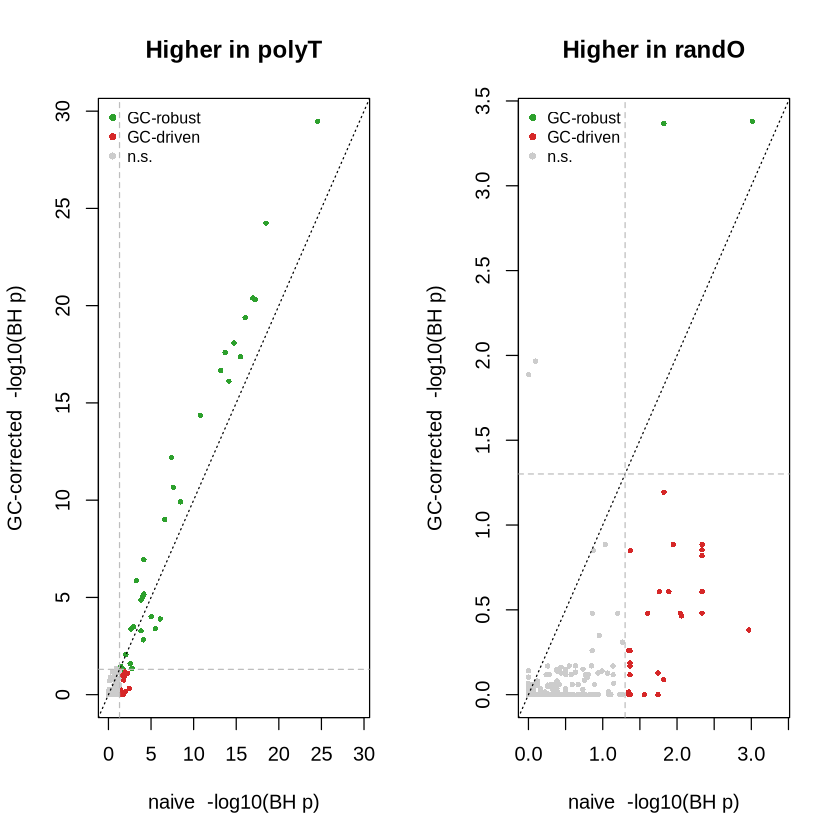

In [4]:
# --- Naive vs GC-corrected significance: points below the diagonal were weakened by GC bias ---
plot_side <- function(d, side) {
  xn <- -log10(pmax(d$padj_naive, 1e-300)); yw <- -log10(pmax(d$padj_wal, 1e-300))
  col <- ifelse(d$classification == "GC-robust", "#2ca02c",
         ifelse(d$classification == "GC-driven", "#d62728", "#cccccc"))
  lim <- max(c(xn, yw, 1))
  plot(xn, yw, col = col, pch = 16, cex = 0.6, xlim = c(0, lim), ylim = c(0, lim),
       xlab = "naive  -log10(BH p)", ylab = "GC-corrected  -log10(BH p)",
       main = paste("Higher in", side))
  abline(0, 1, lty = 3); abline(h = -log10(0.05), col = "grey", lty = 2)
  abline(v = -log10(0.05), col = "grey", lty = 2)
  legend("topleft", c("GC-robust", "GC-driven", "n.s."),
         col = c("#2ca02c", "#d62728", "#cccccc"), pch = 16, bty = "n", cex = 0.8)
}
par(mfrow = c(1, 2))
plot_side(polyT_res, "polyT"); plot_side(randO_res, "randO")

# Top surviving (orthogonal) terms per side
show <- c("category", "numDEInCat", "numInCat", "padj_naive", "padj_wal")
cat("\nTop GC-robust terms — higher in polyT:\n")
print(head(polyT_res[polyT_res$classification == "GC-robust", show], 10))
cat("\nTop GC-robust terms — higher in randO:\n")
print(head(randO_res[randO_res$classification == "GC-robust", show], 10))